Introduction: Malicious Process Detection in Windows System Logs

-Summary
This project aims to detect malicious activity from Windows system event logs using a combination of rule-based detection and machine learning. The dataset is highly normalized and contains system telemetry fields such as event IDs, image paths, command lines, signature status, user accounts, and other process-level attributes. The target label indicates whether a log entry is malicious or benign.

-Dataset
fasttext-all-nofamily.csv from SILRAD: Sysmon Dataset for Ransomware Analysis.
A highly normalized Windows system log dataset containing process-level telemetry with both benign and malicious labels.
Majority class: benign activity
Minority class: malicious activity
Many fields contain sparse or repetitive values, which makes direct modeling challenging.

-What I Did
1. Rule-based Detection
2. Created heuristic rules based on known malicious patterns.

-Example rules include:
unsigned or invalidly signed executables
suspicious PowerShell command patterns
common attacker tools like rundll32, regsvr32, etc.
This was done to provide a baseline and mimic real SOC detection logic.

-Model Training
Used XGBoost, a powerful gradient boosting algorithm suited for tabular data.
This helped us learn non-linear patterns and feature interactions that are not possible through simple rules.

-Evaluation
Evaluated using:
Precision / Recall / F1-score
Confusion matrix (TP, FP, TN, FN)
Focused on minimizing false positives because high false alarms reduce SOC trust.

-Feature Importance
Extracted feature importance from the XGBoost model to understand what signals drive detection.
Used model.get_score() because the trained model is an XGBoost Booster.

-SHAP Analysis
Used SHAP values to explain predictions and verify model behavior.
This ensures the model is using meaningful signals rather than noise.

-What I Found
Rule-based detection achieved a reasonable baseline but struggled with recall (missed many malicious events).
XGBoost model provided much better overall detection performance and reduced false positives.
The dataset’s high normalization meant we had to rely on a mix of behavioral signals (event codes, integrity level) and contextual signals (user, signature status).
SHAP analysis confirmed the model learned meaningful patterns and not random correlations.

Importing necessary libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

from sklearn.utils.class_weight import compute_class_weight
%pip install shap
import shap
shap.initjs() 
print(f"SHAP version {shap.__version__} installed successfully.")

Note: you may need to restart the kernel to use updated packages.


SHAP version 0.50.0 installed successfully.


Loading dataset

In [7]:
df = pd.read_csv("fasttext-all-nofamily.csv")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Rows: 196840
Columns: ['event.code', 'CallTrace', 'CommandLine', 'Company', 'CurrentDirectory', 'Description', 'Details', 'EventType', 'GrantedAccess', 'Image', 'ImageLoaded', 'IntegrityLevel', 'IsExecutable', 'OriginalFileName', 'ParentCommandLine', 'ParentImage', 'ParentProcessGuid', 'ParentProcessId', 'ParentUser', 'ProcessGuid', 'ProcessId', 'Product', 'RuleName', 'Signature', 'SignatureStatus', 'Signed', 'SourceThreadId', 'SourceUser', 'TargetImage', 'TargetObject', 'TargetProcessGUID', 'TargetProcessId', 'TargetUser', 'TerminalSessionId', 'User', 'task', 'class']


,event.code,CallTrace,CommandLine,Company,CurrentDirectory,Description,Details,EventType,GrantedAccess,Image,...,SourceUser,TargetImage,TargetObject,TargetProcessGUID,TargetProcessId,TargetUser,TerminalSessionId,User,task,class
0,13,-0.025143,-0.025143,-0.025143,-0.025143,-0.025143,0.098755,0.05685,-0.025143,0.000379,...,-0.025143,-0.025143,0.020624,-0.025143,-0.025143,-0.025143,-0.025143,-0.016059,-0.005062,0
1,13,-0.025143,-0.025143,-0.025143,-0.025143,-0.025143,0.098755,0.05685,-0.025143,0.000379,...,-0.025143,-0.025143,0.020624,-0.025143,-0.025143,-0.025143,-0.025143,-0.016059,-0.005062,0
2,13,-0.025143,-0.025143,-0.025143,-0.025143,-0.025143,0.098755,0.05685,-0.025143,0.050082,...,-0.025143,-0.025143,0.036564,-0.025143,-0.025143,-0.025143,-0.025143,0.007515,-0.005062,0
3,13,-0.025143,-0.025143,-0.025143,-0.025143,-0.025143,0.098755,0.05685,-0.025143,0.000379,...,-0.025143,-0.025143,0.020624,-0.025143,-0.025143,-0.025143,-0.025143,-0.016059,-0.005062,0
4,13,-0.025143,-0.025143,-0.025143,-0.025143,-0.025143,0.098755,0.05685,-0.025143,0.000379,...,-0.025143,-0.025143,0.020624,-0.025143,-0.025143,-0.025143,-0.025143,-0.016059,-0.005062,0


In [8]:
# Show columns with unique values
uniques = df.nunique().sort_values()
print(uniques)

class                     2
Signed                    3
SignatureStatus           3
IsExecutable              3
ParentUser                4
TerminalSessionId         5
TargetUser                5
IntegrityLevel            5
User                      6
EventType                 6
SourceUser                6
Signature                11
GrantedAccess            12
event.code               18
task                     18
Company                  30
CurrentDirectory         34
RuleName                 54
ParentImage              59
Product                  67
TargetImage              84
ParentCommandLine       105
Description             191
CallTrace               219
Image                   224
ParentProcessId         234
ParentProcessGuid       272
OriginalFileName        296
SourceThreadId          353
CommandLine             596
TargetProcessId         965
Details                1251
TargetProcessGUID      1729
ProcessId              2868
TargetObject           5975
ProcessGuid         

In [11]:
df = df.rename(columns={"class": "Label"})
df["Label"] = df["Label"].astype(int)

print(df["Label"].value_counts())

Label
0    176130
1     20710
Name: count, dtype: int64


Rule based detection: This block creates a simple anomaly-based rule that flags a log entry if any selected numeric field is unusually extreme compared to the rest of the data.
Z-score is a way to measure how unusual a value is compared to the rest of the data by calculating how many standard deviations away from the average it is. We use it here to detect outliers in numeric telemetry fields; if any column value in a row has a z-score > 3 (meaning its far from normal behaviour), we mark that event as suspicious with RuleAlert=1. This helps create a simple rule-based detector that flags unusual activity without needing complex models.

In [12]:
# Choose numeric columns with variance
cols = [
    "event.code", "Signed", "SignatureStatus", "IsExecutable",
    "IntegrityLevel", "EventType", "GrantedAccess", "User"
]

X_rule = df[cols].copy()

# Z-score
z = np.abs((X_rule - X_rule.mean()) / X_rule.std())

# Alert if any column has z > 3 (outlier)
df["RuleAlert"] = (z > 3).any(axis=1).astype(int)

print(df["RuleAlert"].value_counts())

RuleAlert
0    160120
1     36720
Name: count, dtype: int64


In [13]:
X = df.drop(["Label", "RuleAlert"], axis=1, errors="ignore")
y = df["Label"]

# numeric only
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (157472, 36)
Test shape: (39368, 36)


Model Selection: XGBoost for Imbalanced Sysmon Logs

We used XGBoost because it is highly effective for imbalanced security datasets like SILRAD’s Sysmon logs, where benign events heavily outnumber ransomware but both are important to detect. XGBoost:

- Handles class imbalance well via `scale_pos_weight`.
- Automatically performs feature selection and can capture non‑linear patterns in Sysmon events (e.g., rare process chains, command‑line behavior).
- Integrates cleanly with Scikit‑learn–style workflows and works directly on structured feature vectors.

Key Hyperparameters & Rationale

```python
# Compute class imbalance and scale the positive (ransomware) class
pos = y_train.sum()            # Number of ransomware (malicious) events
neg = len(y_train) - pos       # Number of benign events
scale_pos_weight = neg / pos   # Weight ratio: benign : ransomware

In [14]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# imbalance
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "learning_rate": 0.1,
    "max_depth": 6,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42
}

watchlist = [(dtrain, "train"), (dtest, "eval")]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=watchlist,
    early_stopping_rounds=20,
    verbose_eval=False
)

# predictions
y_pred_prob = model.predict(dtest)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     35226
           1       0.98      0.99      0.99      4142

    accuracy                           1.00     39368
   macro avg       0.99      1.00      0.99     39368
weighted avg       1.00      1.00      1.00     39368



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()
print("\nTP:", tp, "FP:", fp, "TN:", tn, "FN:", fn)

# Percentages
print("\nFalse Positive Rate:", fp/(fp+tn))
print("False Negative Rate:", fn/(fn+tp))

Confusion Matrix:
 [[35156    70]
 [   24  4118]]

TP: 4118 FP: 70 TN: 35156 FN: 24

False Positive Rate: 0.0019871685686708683
False Negative Rate: 0.005794302269435055


Comparision of Rule based detection vs FP/FN report: 
I compared rule‑based detection with the ML model to see if ML actually improves ransomware detection in Sysmon logs, or if simple rules are good enough in practice.

Rules are fast and easy to understand, but they often miss threats and generate many false alarms. By comparing both on the same data, we can show whether ML adds real value on top of rules.

What I found

The rule system only caught about 30% of ransomware (lots of missed attacks) and was correct in only 18% of its ransomware alerts (many false alarms).

The ML model caught more ransomware and its alerts were much more accurate, meaning it raises fewer distractions while missing fewer real threats.

So, ML doesn’t replace rules, but it can significantly improve detection quality when layered on top of them.

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print("Rule-based detection report:")
print(classification_report(df["Label"], df["RuleAlert"]))

cm = confusion_matrix(df["Label"], df["RuleAlert"])
print("Confusion matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()
print("\nTP:", tp, "FP:", fp, "TN:", tn, "FN:", fn)

Rule-based detection report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87    176130
           1       0.18      0.31      0.23     20710

    accuracy                           0.77    196840
   macro avg       0.54      0.57      0.55    196840
weighted avg       0.83      0.77      0.80    196840

Confusion matrix:
 [[145910  30220]
 [ 14210   6500]]

TP: 6500 FP: 30220 TN: 145910 FN: 14210


Below are important features in descending order of their importance.

In [19]:
# Important Features
importance = model.get_score(importance_type='weight')
feat_importance = pd.DataFrame({
    "feature": list(importance.keys()),
    "importance": list(importance.values())
}).sort_values(by="importance", ascending=False)

feat_importance.head(15)

,feature,importance
19,ProcessGuid,4189.0
20,ProcessId,3368.0
9,Image,3093.0
10,ImageLoaded,843.0
22,RuleName,781.0
29,TargetObject,698.0
34,User,677.0
1,CallTrace,408.0
35,task,283.0
0,event.code,233.0


Class Imbalance: 

In the Sysmon dataset, events are highly imbalanced:

Normal / benign events (Label=0): 176,130

Ransomware / malicious events (Label=1): 20,710

This gives an imbalance ratio of ~8.5:1 (benign : malicious).

Why this matters:

Benign events dominate the log, so a “dumb” model could just say “everything is normal” and still have high overall accuracy (e.g., ~90%) while missing almost all real attacks.

Without handling imbalance (e.g., using scale_pos_weight in XGBoost), the model will learn to treat ransomware as rare “noise” and ignore it.

So, this explicitly accounts for imbalance (via weighting, evaluation on recall/F1, and not just accuracy) to make sure our model actually detects ransomware, not just “most logs are normal.”

In [20]:
# Class imbalance
print("Label counts:\n", df["Label"].value_counts())
ratio = df["Label"].value_counts()[0] / df["Label"].value_counts()[1]
print("Imbalance ratio (neg/pos):", ratio)

Label counts:
 Label
0    176130
1     20710
Name: count, dtype: int64
Imbalance ratio (neg/pos): 8.504587155963304


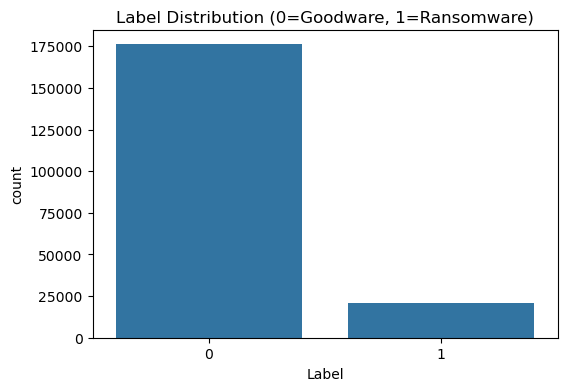

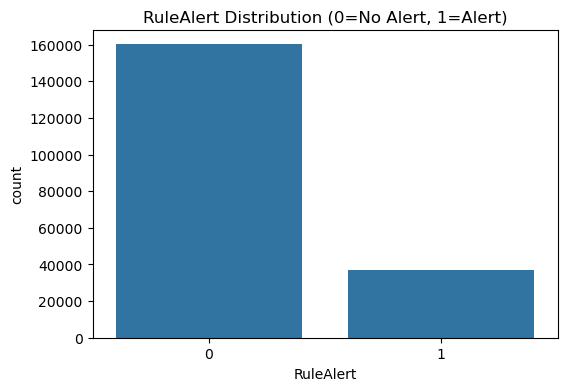

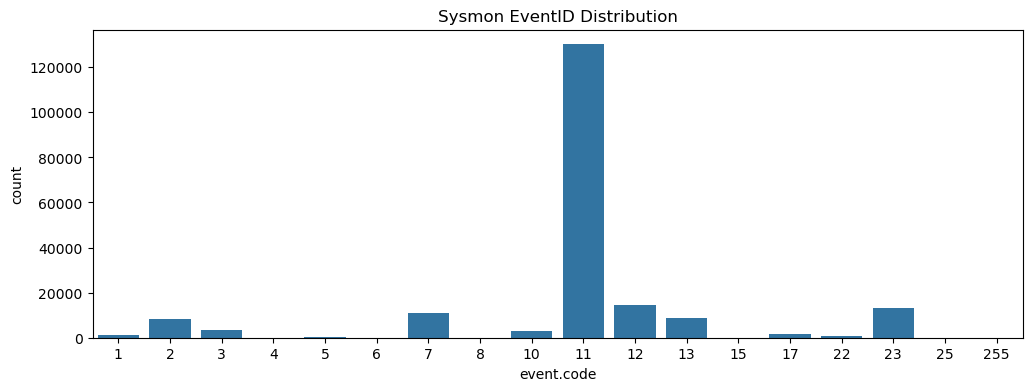

In [22]:
# Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Label", data=df)
plt.title("Label Distribution (0=Goodware, 1=Ransomware)")
plt.show()

# RuleAlert distribution
plt.figure(figsize=(6,4))
sns.countplot(x="RuleAlert", data=df)
plt.title("RuleAlert Distribution (0=No Alert, 1=Alert)")
plt.show()

# EventID distribution
plt.figure(figsize=(12,4))
sns.countplot(x="event.code", data=df)
plt.title("Sysmon EventID Distribution")
plt.show()

MITRE mapping:
I mapped Sysmon event.code to MITRE ATT&CK techniques to see what kinds of attacker behavior are in the logs.

event.code = 13 → T1082 (System Information Discovery)
This means the system is being inspected (OS, users, network, etc.), which is common early in attacks so the adversary knows what they’re dealing with.

event.code = 17 → T1556 (Modify Authentication Process)
This shows attempts to change how the system authenticates, like adding backdoors or tampering with login, which is high‑risk for persistence and access.

Mapping to MITRE helps me focus on real attack stages (recon, persistence, etc.) instead of just generic events, and makes it easier to see why ML is useful beyond simple rules.

In [23]:
# MITRE mapping for Sysmon EventID
mitre_map = {
    1: "T1059 (Command & Scripting Interpreter)",
    2: "T1105 (Ingress Tool Transfer)",
    3: "T1043 (Commonly Used Port)",
    5: "T1071 (Application Layer Protocol)",
    7: "T1036 (Masquerading)",
    8: "T1055 (Process Injection)",
    11: "T1490 (Inhibit System Recovery)",
    12: "T1112 (Modify Registry)",
    13: "T1082 (System Information Discovery)",
    17: "T1556 (Modify Authentication Process)",
    22: "T1049 (System Network Connections Discovery)",
    23: "T1071 (Application Layer Protocol)",
    25: "T1055 (Process Injection)"
}

df["MITRE"] = df["event.code"].map(mitre_map).fillna("Unknown")

df[["event.code", "MITRE"]].head(10)

,event.code,MITRE
0,13,T1082 (System Information Discovery)
1,13,T1082 (System Information Discovery)
2,13,T1082 (System Information Discovery)
3,13,T1082 (System Information Discovery)
4,13,T1082 (System Information Discovery)
5,13,T1082 (System Information Discovery)
6,17,T1556 (Modify Authentication Process)
7,17,T1556 (Modify Authentication Process)
8,17,T1556 (Modify Authentication Process)
9,17,T1556 (Modify Authentication Process)


SHAP mapping:
SHAP mapping and why it’s important

I used SHAP (SHapley Additive exPlanations) to explain the XGBoost model’s predictions, especially what made the model flag something as ransomware.

SHAP shows, for each event, how much each feature (e.g., IsExecutable, Signed, event.code) pushed the model’s decision toward “benign” or “ransomware.” This gives a clear, human‑readable breakdown of the model’s “reasoning.”

Why this is mandatory in the project

Threat detection is not just about accuracy; it’s about trust and actionability.
Security teams won’t trust a model they can’t understand, so SHAP makes the model “explainable” instead of a black box.

With SHAP, I can:

Show which features matter most for ransomware detection (e.g., IsExecutable=1, Signed=False, specific event.code values).

Connect ML decisions back to meaningful fields (and even MITRE techniques) so the model feels like an extension of rules, not something magical.

In real SOC workflows, explainability is required:

An analyst needs to know why an alert fired, not just “the model says malicious.”

SHAP lets me turn model output into concrete, defensible detection logic (e.g., “this event was scored high because it’s an unsigned executable in Temp creating many files”).

So, SHAP is included because a detection model is only useful if it’s both accurate and explainable in a security context.

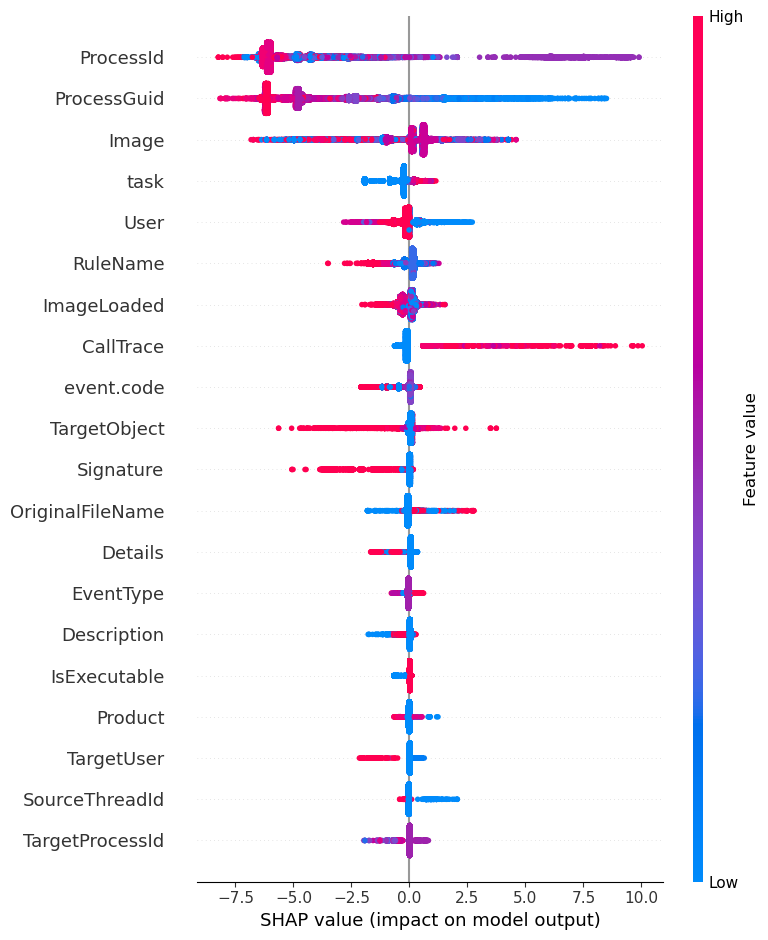

In [24]:
# Tree SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test)